# Rad-CAT BETA
This code will generate artifical RHI scans for the gate location nearest to the research aircraft 
and will also provide other products like a PPI scan of the elevation that the aircraft is currently 
on and some basic statistics like the reflectivity value associated with the location of the aircraft.
There are also other things that may get included later on but for right now this is the extent of it.

In [1]:
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.feature as cfeature
import xarray as xr
import os
import imageio.v2 as imageio
import pandas as pd
import time
import io
import cmweather
from datetime import datetime
import numpy as np
import matplotlib.ticker as ticker


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



# Sudo RHI and PPI Scan Given Aircraft Location and Time
This code takes in the latitude, longitude, altitude, and time of the aircraft and will return a sudo RHI and PPI scan for the location and time of the aircraft along with a display of where the aircraft is at relative to the scans that are displayed. This code requires a radar file that is just before the start of the flight in the case that the elevation scan in the file that does line up with the aircraft isn't complete yet. Otherwise this code will just use the radar file that has the closest scan both spatially and temporally. 

In [2]:
# Reading in and parsing aircraft track information
citation_nav = pd.read_csv('flight_data/2011-05-20_CITATION.dat', sep = ',', header = None)
cit_time = citation_nav.iloc[:, 1]
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]
cit_alt = citation_nav.iloc[:, 5]

In [3]:
def radar_data_finder(cit_time, cit_lat, cit_lon, cit_alt):
    '''
    This function takes in aircraft time, latitude, longitude, and altitude 
    and returns the data file that should be plotted with the most accurate 
    and up to date data given the location and timing of the aircraft.
    '''
    
    # Initial read in of all possible radar times that could be plotted 
    with os.scandir('C-SAPR_May_20_2011/') as entries:
        radar_files = list(entries)

    # List creation of all possible radar files 
    radar_file_times = []
    for x in range(len(radar_files)):
        radar_file_times.append(datetime.strptime(radar_files[x].name[21:36], "%Y%m%d.%H%M%S").timestamp())

    radar_file_times = np.array(radar_file_times)

    # Catch to see if the aircraft actually has radar files associated with it 
    if cit_time >= radar_file_times[1]:
        # Finds the file that is closest to the aircraft time 
        time_index = np.argmin(abs(radar_file_times - cit_time))
    
        # Read in of data array of possible radar file 
        data = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[time_index].name)
    
        # Finds the appropriate sweep given the loation of the aircraft 
        vert_radar_profile = pyart.util.columnsect.get_field_location(data, cit_lat, cit_lon)
        sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt * 1000)))
    
        # Finds the end time of the sweep that is appropriate to the aircraft 
        sweep_time = data.extract_sweeps([sweep]).time['data'].max()
    
        # Compares the end of the sweep time with the aircraft time to see if this radar file is appropriate or if the radar file previous is appropriate 
        if (sweep_time + radar_file_times[time_index]) <= cit_time:
            return data
        else:
            try:
                data = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[time_index - 1].name)
                return data
            except FileNotFoundError:
                raise ValueError("There are no matching radar files with the given aircraft time. \n Try adding radar file that started before the aircraft time.")
            
    else:
        raise ValueError("There are no matching radar files with the given aircraft time. \n Try adding radar file that started before the aircraft time.")

In [4]:
time_step = 357
data = radar_data_finder(datetime.strptime(cit_time[time_step][0:19], "%Y-%m-%dT%H:%M:%S").timestamp(), cit_lat[time_step], cit_lon[time_step], (cit_alt[time_step] / 1000))
aircraft_lat = cit_lat[time_step]
aircraft_lon = cit_lon[time_step]
aircraft_alt = cit_alt[time_step] / 1000

Radar sweep 5
Aircraft Latitude: 36.384 Aircraft Longitude: -97.202
Aircraft Altitude: 6967.72m


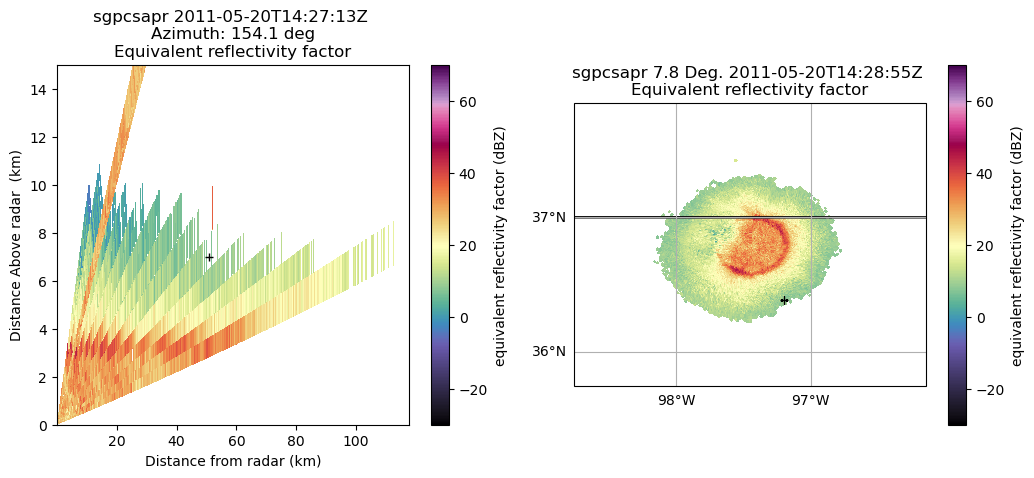

In [6]:
# Define parameters needed for plotting
radar_lat = data.latitude['data'][0]
radar_lon = data.longitude['data'][0]

radar_azimuth = pyart.util.for_azimuth(radar_lat, aircraft_lat, radar_lon, aircraft_lon)
aircraft_distance = pyart.util.sphere_distance(radar_lat, aircraft_lat, radar_lon, aircraft_lon) / 1000 # This converts to kilometers

# Convert the radar data to a graphable display object
display = pyart.graph.RadarMapDisplay(data)

# Define the projection used in the PPI map
projection = ccrs.PlateCarree()

# Set figure size for the plots
fig = plt.figure(figsize = (11,9))

# Define the axis for the RHI map plot
ax = fig.add_axes([0.06, 0.50, 0.40, 0.40])

# Plotting of the artifical RHI map
display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                           ax = ax, 
                           target_azimuth = radar_azimuth, 
                           vmin = -30,
                           vmax = 70,
                           cmap = 'ChaseSpectral')

# This plots the location of the aircraft on the artifical RHI map
ax.plot(aircraft_distance, aircraft_alt, marker = '+', color = 'black')

# Limit set to the y-axis to make sure map is proportional 
ax.set_ylim(0, 15)

# Define the axis that the PPI map will be plotted to 
ax1 = fig.add_axes([0.53, 0.50, 0.40, 0.40], projection = projection)
ax1.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

# This code will find the sweep that the aircraft is most closest to and plot it in the PPI map 
vert_radar_profile = pyart.util.columnsect.get_field_location(data, aircraft_lat, aircraft_lon)
sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (aircraft_alt * 1000)))

# PPI display map
display.plot_ppi_map('corrected_reflectivity_horizontal', 
                        ax = ax1,
                        sweep = sweep,
                        vmin = -30,
                        vmax = 70, 
                        cmap = 'ChaseSpectral')

# This plots the location of the aircraft on the PPI map
ax1.plot(aircraft_lon, aircraft_lat, marker = '+', color = 'black')

# This will find the reflectivity associated with the given location of the aircraft
aircraft_reflectivity = vert_radar_profile.corrected_reflectivity_horizontal.sel(height=(aircraft_alt * 1000), method = 'nearest').data

# Output of aircraft reflectivity and radar sweep that the aircraft is located in
#print(f'Aircraft Reflectivity: {round(int(aircraft_reflectivity), 0)}dBz')
print(f'Radar sweep {sweep + 1}')
print(f'Aircraft Latitude: {aircraft_lat:.3f} Aircraft Longitude: {aircraft_lon:.3f}')
print(f'Aircraft Altitude: {aircraft_alt * 1000}m')

plt.show()

# Aircraft and Radar Sync 
This code will access the location of the Citation research aircraft and will find the appropriate radar gates above, on top, and below the aircraft and will then take those properties and associate them with that given flight leg point. This will allow for a suite of data to be provided for the aircraft this data will also include air temperature, altitude, dewpoint temperature, liquid water content, Ice water content, and total concentration. Note that there may be other parameters that will be added in future iterations of this code. 

In [5]:
# Reading in and parsing aircraft track information
citation_nav = pd.read_csv('flight_data/2011-05-20_CITATION.dat', sep = ',', header = None)
cit_time = citation_nav.iloc[:, 1]
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]
cit_alt = citation_nav.iloc[:, 5]

In [75]:
time_step = 400
data = radar_data_finder(datetime.strptime(cit_time[time_step][0:19], "%Y-%m-%dT%H:%M:%S").timestamp(), cit_lat[time_step], cit_lon[time_step], (cit_alt[time_step] / 1000))

In [2]:
ds = xr.open_dataset('C-SAPR_May_20_2011/sgpcsaprsurcmacI7.c0.20110520.143552.nc.v0')

In [15]:
def radar_gate_finder(citation_nav):
    '''
    This funciton takes in aircraft navigation data and compares it 
    against radar files. It then returns which data file it requires 
    data from.
    '''
    cit_time = aircraft_nav.iloc[:, 1]

    # Initial read in of all possible radar times that could be plotted 
    with os.scandir('C-SAPR_May_20_2011/') as entries:
        radar_files = list(entries)

    # List creation of all possible radar files 
    radar_file_times = []
    for x in range(len(radar_files)):
        radar_file_times.append(datetime.strptime(radar_files[x].name[21:36], "%Y%m%d.%H%M%S").timestamp())

    radar_file_times = np.array(radar_file_times)

    for number_files in range(len(radar_file_times) - 1):
        data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
        data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)

        # Find valid aircraft times that overlap the second radar data file
        file_start_time = radar_file_times[number_files + 1]
        file_end_time = radar_file_times[number_files + 1] + data.extract_sweeps([data.nsweeps - 1]).time['data'].max()

In [2]:
data = pyart.io.read('C-SAPR_May_20_2011/sgpcsaprsurcmacI7.c0.20110520.143552.nc.v0')

In [17]:
radar_gate_finder(citation_nav)

In [140]:
#===============================================================
# This funciton takes in aircraft navigation data and compares it 
# against radar files. It then returns which data file it requires 
# data from.
#===============================================================

cit_time = citation_nav.iloc[:, 1]
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]
cit_alt = citation_nav.iloc[:, 5]

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append(datetime.strptime(radar_files[x].name[21:36], "%Y%m%d.%H%M%S").timestamp())

radar_file_times = np.array(radar_file_times)

reflec_data_tot = []
valid_time_tot = []
for number_files in range(len(radar_file_times) - 1):
    data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
    data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)
    
    #===================================================================================
    # Find valid aircraft times that overlap the end of the max sweep of the first radar 
    # data file to the end of the max sweep in the second radar file.
    #===================================================================================
    
    file_start_time = radar_file_times[number_files] + data1.extract_sweeps([data1.nsweeps - 1]).time['data'].max()
    file_end_time = radar_file_times[number_files + 1] + data2.extract_sweeps([data2.nsweeps - 1]).time['data'].max()

    for time in range(len(cit_time)):
        cit_time_ind = datetime.strptime(cit_time[time][0:19], "%Y-%m-%dT%H:%M:%S").timestamp()
        if cit_time_ind >= file_start_time and cit_time_ind <= file_end_time:
            valid_time_list = np.append(valid_time_list, cit_time[time])

            #===================================================================================
            # Find which sweep the aircraft is in and then what appropriate radar file should be
            # Used for that given sweep.
            #===================================================================================

            vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cit_lat[time], cit_lon[time])
            sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt[time])))
    
            sweep_time = data2.extract_sweeps([sweep]).time['data'].max()
            
            if (sweep_time + radar_file_times[number_files + 1]) <= cit_time_ind:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cit_lat[time], cit_lon[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt[time])))
                
                # Check to see if an above and below scan can be provided or if only a center scan can be returned
                if sweep == 0 or sweep == data2.nsweeps:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan
                    
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]
                
            else:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data1, cit_lat[time], cit_lon[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt[time])))
                
                # Check to see if an above and below scan can be provided or if only a center scan can be returned
                if sweep == 0 or sweep == data1.nsweeps:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan
                    
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]

            reflec_data = [reflec_data_below, reflec_data_ontop, reflec_data_above]
            reflec_data_tot.append(reflec_data)
            valid_time_tot.append(cit_time[time])

reflec_data_tot = np.array(reflec_data_tot)
valid_time_tot = np.array(valid_time_tot)

In [141]:
sweep_options = ['below', 'in', 'above']
aircraft_reflectivity = xr.DataArray(
    data=reflec_data_tot,
    dims=["time", "sweep"],
    coords={"time": valid_time_tot, "sweep" : sweep_options})


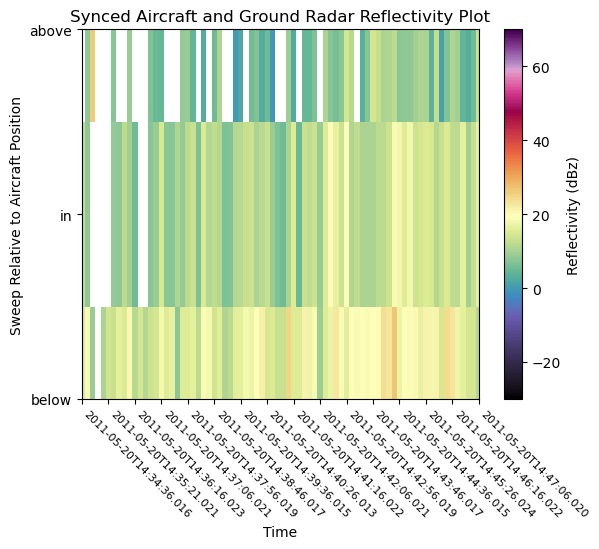

In [142]:
fig, ax = plt.subplots()
a = aircraft_reflectivity.plot(x = 'time', 
                           ax = ax, 
                           cmap = 'ChaseSpectral',
                           vmin = -30,
                           vmax = 70, 
                           cbar_kwargs={"label": "Reflectivity (dBz)"})

ax.set_title('Synced Aircraft and Ground Radar Reflectivity Plot')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.xlabel('Time')
plt.ylabel('Sweep Relative to Aircraft Position')
plt.xticks(rotation = -45, ha = 'left', size = 8)
plt.show()

In [138]:
radar_files[1].name[4:19]

'20110520_142857'